In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA, Imputer
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.functions import col, when, sum, isnan
import matplotlib.pyplot as plt
import numpy as np

spark = SparkSession.builder \
    .appName("SpotifyRecommandation") \
    .config("spark.driver.memory", "12g") \
    .config("spark.executor.memory", "12g") \
    .config("zspark.executor.cores", "2") \
    .getOrCreate()

df = spark.read.csv(
    "hdfs://hadoop-namenode-1:8020/data/data.csv",
    header=True, inferSchema=True
).dropDuplicates()

df.printSchema()
df.show(5)

root
 |-- valence: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- explicit: string (nullable = true)
 |-- id: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- key: string (nullable = true)
 |-- liveness: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- tempo: string (nullable = true)

+-------+----+------------+--------------------+------------+-----------+------+--------+--------------------+----------------+---+--------+--------+----+--------------------+----------+------------+-----------+-------+
|valence|year|a

In [2]:
audio_cols = [
    "danceability","energy","valence","acousticness",
    "instrumentalness","liveness","speechiness","tempo"
]

for c in audio_cols:
    df = df.withColumn(c, col(c).cast("double"))


In [3]:
imputer = Imputer(
    inputCols=audio_cols,
    outputCols=audio_cols
).setStrategy("mean")

df_imputed = imputer.fit(df).transform(df)

print("DataFrame nettoyé :")
df_imputed.printSchema()

print("\nAperçu des données :")
df_imputed.select(audio_cols).show(5)

print("\nValeurs nulles restantes :")
df_imputed.select([
    col(c).isNull().cast("int").alias(c) for c in audio_cols
]).groupBy().sum().show()


DataFrame nettoyé :
root
 |-- valence: double (nullable = true)
 |-- year: integer (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- artists: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- duration_ms: string (nullable = true)
 |-- energy: double (nullable = true)
 |-- explicit: string (nullable = true)
 |-- id: string (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- key: string (nullable = true)
 |-- liveness: double (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- name: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- tempo: double (nullable = true)


Aperçu des données :
+------------+------+-------+------------+----------------+--------+-----------+-------+
|danceability|energy|valence|acousticness|instrumentalness|liveness|speechiness|  tempo|
+------------+-

In [4]:
assembler = VectorAssembler(
    inputCols=audio_cols,
    outputCol="audio_features"
)
df_assembled = assembler.transform(df_imputed)

df_assembled.select("audio_features").show(3, truncate=False)


+----------------------------------------------------+
|audio_features                                      |
+----------------------------------------------------+
|[0.573,0.246,0.965,0.907,0.867,0.0752,0.224,205.419]|
|[0.424,0.309,0.327,0.996,0.946,0.175,0.0591,127.24] |
|[0.514,0.158,0.75,0.995,0.943,0.273,0.0488,123.55]  |
+----------------------------------------------------+
only showing top 3 rows



In [5]:
# Normalize features

scaler = StandardScaler(inputCol="audio_features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

print("Aperçu des features après normalisation :")
df_scaled.select("scaled_features").show(3, truncate=False)

Aperçu des features après normalisation :
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|scaled_features                                                                                                                                                        |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[0.2012945807312575,-0.03948991287920533,1.658832480649482,1.076687586079962,-0.011373377187380017,-0.0035670336595607158,-0.049419206510371586,1.3022841077121174]    |
|[-0.6469198030696822,-0.03948524544947045,-0.7674515885751875,1.3133944763166674,-0.011348182624429732,-0.0034653234053042604,-0.05110279644677744,0.1346287263960508] |
|[-0.1345755443979734,-0.03949643246359691,0.8411975670392879,1.3107348483364798,-0.011349139379984807,-0.00

In [15]:
pca = PCA(k=8, inputCol="scaled_features", outputCol="pca_features")
model_pca = pca.fit(df_scaled)
df_pca = model_pca.transform(df_scaled)

explained = model_pca.explainedVariance.toArray()
cumvar    = np.cumsum(explained)

for i, (e, c) in enumerate(zip(explained, cumvar), start=1):
    print(f"PC{i:>2} : {e*100:6.2f} %    (cumul : {c*100:6.2f} %)")

PC 1 :  21.53 %    (cumul :  21.53 %)
PC 2 :  15.62 %    (cumul :  37.14 %)
PC 3 :  12.51 %    (cumul :  49.65 %)
PC 4 :  12.50 %    (cumul :  62.16 %)
PC 5 :  12.15 %    (cumul :  74.31 %)
PC 6 :  10.59 %    (cumul :  84.89 %)
PC 7 :   9.71 %    (cumul :  94.61 %)
PC 8 :   5.39 %    (cumul : 100.00 %)


In [16]:
pca = PCA(k=5, inputCol="scaled_features", outputCol="pca_features")
model_pca = pca.fit(df_scaled)
df_pca = model_pca.transform(df_scaled).cache()

In [17]:
df_pca.select("pca_features").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------+
|pca_features                                                                                            |
+--------------------------------------------------------------------------------------------------------+
|[-0.8386710557505083,-0.2940212101271953,0.17774389241791144,0.021174528372353365,-0.6315129552800846]  |
|[1.4040478678234865,-0.32593648378741485,0.011506952927231055,0.009353645649981429,0.13791999950127073] |
|[0.0901380463975956,-0.0019828266797729272,0.003537779960515942,0.040383769287759934,0.3667051838132458]|
|[-1.421504853284012,0.48818865914707604,-0.043646691757937305,0.08000479860631238,0.790386019166411]    |
|[0.5209032662625668,-0.07715029580850045,-0.004110141632002699,0.03150048711951185,0.3405499363339976]  |
+--------------------------------------------------------------------------------------------------------+
only showing top 5 rows



In [18]:
# Clustering

K=2 → WSSSE=844000.21
K=3 → WSSSE=701530.72
K=4 → WSSSE=555030.18
K=5 → WSSSE=561612.91
K=6 → WSSSE=334812.71
K=7 → WSSSE=316008.04
K=8 → WSSSE=148153.68
K=9 → WSSSE=143185.54
K=10 → WSSSE=111899.03
K=11 → WSSSE=100965.08
K=12 → WSSSE=88247.22
K=13 → WSSSE=71989.53
K=14 → WSSSE=77106.91
K=15 → WSSSE=72417.12


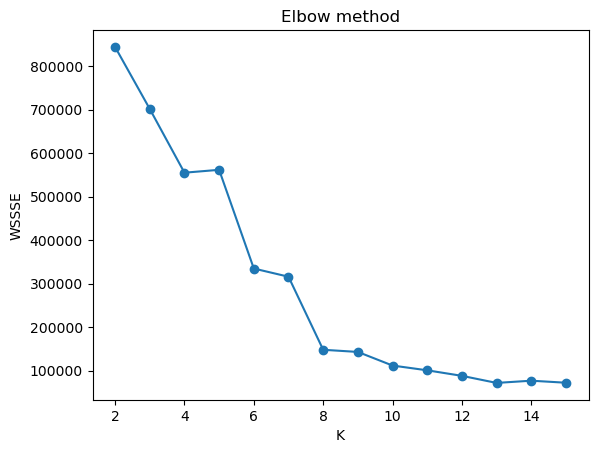

In [25]:
distortions = []
ks = list(range(2, 16)) 


for k in ks:
    km = KMeans(featuresCol="pca_features", k=k, seed=42)
    mdl = km.fit(df_pca)
    
    cost = mdl.summary.trainingCost
    distortions.append(cost)
    
    print(f"K={k} → WSSSE={cost:.2f}")

plt.plot(ks, distortions, marker='o')
plt.xlabel('K')
plt.ylabel('WSSSE')
plt.title('Elbow method')
plt.show()

K=2 → Silhouette=0.9999
K=3 → Silhouette=0.4357
K=4 → Silhouette=0.4877
K=5 → Silhouette=0.9832
K=6 → Silhouette=0.3379
K=7 → Silhouette=0.2963
K=8 → Silhouette=0.5610
K=9 → Silhouette=0.5623
K=10 → Silhouette=0.5170
K=11 → Silhouette=0.5222
K=12 → Silhouette=0.5029
K=13 → Silhouette=0.5118
K=14 → Silhouette=0.4980
K=15 → Silhouette=0.4935
K=16 → Silhouette=0.5140
K=17 → Silhouette=0.4706
K=18 → Silhouette=0.4981
K=19 → Silhouette=0.4548
K=20 → Silhouette=0.4618
K=21 → Silhouette=0.4682
K=22 → Silhouette=0.4824
K=23 → Silhouette=0.4862
K=24 → Silhouette=0.4832
K=25 → Silhouette=0.4766
K=26 → Silhouette=0.4831
K=27 → Silhouette=0.4782
K=28 → Silhouette=0.4691
K=29 → Silhouette=0.4669
K=30 → Silhouette=0.4644
K=31 → Silhouette=0.4675
K=32 → Silhouette=0.4658
K=33 → Silhouette=0.4672
K=34 → Silhouette=0.4563
K=35 → Silhouette=0.4560
K=36 → Silhouette=0.4678
K=37 → Silhouette=0.4684
K=38 → Silhouette=0.4610
K=39 → Silhouette=0.4628
K=40 → Silhouette=0.4679
K=41 → Silhouette=0.4598
K=42 → S

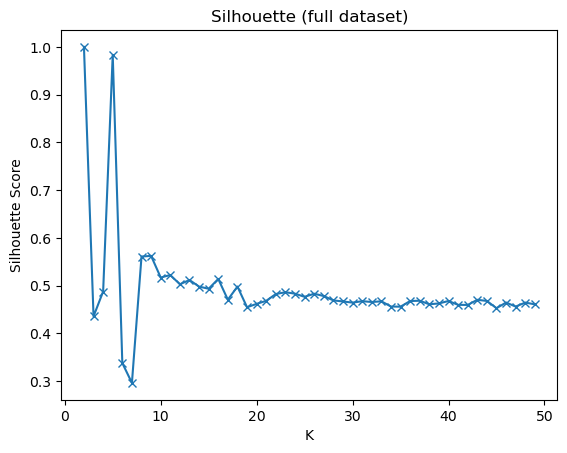

In [24]:
evaluator = ClusteringEvaluator(
    featuresCol="pca_features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

ks = list(range(2, 50)) 

sil_scores = []
for k in ks:
    km = KMeans(featuresCol="pca_features", k=k, seed=42)
    preds = km.fit(df_pca).transform(df_pca)
    score = evaluator.evaluate(preds)
    sil_scores.append(score)
    # print(f"K={k} → Silhouette={score:.4f}")

plt.plot(ks, sil_scores, marker='x')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette (full dataset)')
plt.show()

In [27]:
K_OPTIMAL = 5

print(f"Entraînement du modèle final avec k={K_OPTIMAL}...")

kmeans_final = KMeans(featuresCol="pca_features", k=K_OPTIMAL, seed=42)
modele_kmeans_final = kmeans_final.fit(df_pca)

df_clustered = modele_kmeans_final.transform(df_pca)

print("Clusters assignés avec succès !")
df_clustered.select("artists", "name", "prediction").show(10, truncate=False)

df_clustered.write.mode("overwrite").parquet("hdfs://hadoop-namenode-1:8020/user/jovyan/spotify_clustered.parquet")

Entraînement du modèle final avec k=5...
Clusters assignés avec succès !
+--------------------------------------------------+------------------------------------------------------------------------------------+----------+
|artists                                           |name                                                                                |prediction|
+--------------------------------------------------+------------------------------------------------------------------------------------+----------+
|['Louis Armstrong & His Hot Seven']               |Weary Blues                                                                         |0         |
|['Francisco Canaro']                              |Sobin Blue - Remasterizado                                                          |0         |
|['Ignacio Corsini']                               |Ojerosa - Remasterizado                                                             |0         |
|['Francisco Canaro']            